In [86]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/khushbookumaribts/pokemon/PokemonData.csv
/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/pokemon.csv
/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/images/throh.png
/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/images/samurott.png
/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/images/venomoth.png
/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/images/latios.png
/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/images/shinx.png
/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/images/durant.png
/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/images/primarina.png
/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/images/geodude.png
/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/images/popplio.png
/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/images/wingull.png
/kaggle/input/datasets/vishalsubbiah/pokemon-images-a

In [88]:
import pandas as pd

In [89]:
import numpy as np

In [90]:
df=pd.read_csv('/kaggle/input/datasets/khushbookumaribts/pokemon/PokemonData.csv')

In [91]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Num         800 non-null    int64 
 1   Name        800 non-null    object
 2   Type1       800 non-null    object
 3   Type2       414 non-null    object
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   SpAtk       800 non-null    int64 
 8   SpDef       800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB


,Num,Name,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [92]:
df['Type2']=df['Type2'].fillna(df['Type2'].mode()[0])

In [93]:
df['Type2'].unique()

array(['Poison', 'Flying', 'Dragon', 'Ground', 'Fairy', 'Grass',
       'Fighting', 'Psychic', 'Steel', 'Ice', 'Rock', 'Dark', 'Water',
       'Electric', 'Fire', 'Ghost', 'Bug', 'Normal'], dtype=object)

In [94]:
# df['Type2'].shape
df['Type1'].shape

(800,)

In [95]:

df.drop_duplicates(inplace=True)

In [96]:
df['Type1']=df['Type1'].str.lower()
df
df['Type2']=df['Type2'].str.lower()
df['Name']=df['Name'].str.lower()
df['Legendary']=df['Legendary'].replace({False:0,True:1})

/tmp/ipykernel_58/4277779603.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Legendary']=df['Legendary'].replace({False:0,True:1})


In [97]:
df

,Num,Name,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation,Legendary
0,1,bulbasaur,grass,poison,45,49,49,65,65,45,1,0
1,2,ivysaur,grass,poison,60,62,63,80,80,60,1,0
2,3,venusaur,grass,poison,80,82,83,100,100,80,1,0
3,3,venusaurmega venusaur,grass,poison,80,100,123,122,120,80,1,0
4,4,charmander,fire,flying,39,52,43,60,50,65,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,diancie,rock,fairy,50,100,150,100,150,50,6,1
796,719,dianciemega diancie,rock,fairy,50,160,110,160,110,110,6,1
797,720,hoopahoopa confined,psychic,ghost,80,110,60,150,130,70,6,1
798,720,hoopahoopa unbound,psychic,dark,80,160,60,170,130,80,6,1


In [98]:


df=pd.get_dummies(df,columns=['Type1','Type2'],dtype=int)
df

,Num,Name,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation,Legendary,...,Type2_ghost,Type2_grass,Type2_ground,Type2_ice,Type2_normal,Type2_poison,Type2_psychic,Type2_rock,Type2_steel,Type2_water
0,1,bulbasaur,45,49,49,65,65,45,1,0,...,0,0,0,0,0,1,0,0,0,0
1,2,ivysaur,60,62,63,80,80,60,1,0,...,0,0,0,0,0,1,0,0,0,0
2,3,venusaur,80,82,83,100,100,80,1,0,...,0,0,0,0,0,1,0,0,0,0
3,3,venusaurmega venusaur,80,100,123,122,120,80,1,0,...,0,0,0,0,0,1,0,0,0,0
4,4,charmander,39,52,43,60,50,65,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,diancie,50,100,150,100,150,50,6,1,...,0,0,0,0,0,0,0,0,0,0
796,719,dianciemega diancie,50,160,110,160,110,110,6,1,...,0,0,0,0,0,0,0,0,0,0
797,720,hoopahoopa confined,80,110,60,150,130,70,6,1,...,1,0,0,0,0,0,0,0,0,0
798,720,hoopahoopa unbound,80,160,60,170,130,80,6,1,...,0,0,0,0,0,0,0,0,0,0


In [99]:
df.isnull().sum()

Num               0
Name              0
HP                0
Attack            0
Defense           0
SpAtk             0
SpDef             0
Speed             0
Generation        0
Legendary         0
Type1_bug         0
Type1_dark        0
Type1_dragon      0
Type1_electric    0
Type1_fairy       0
Type1_fighting    0
Type1_fire        0
Type1_flying      0
Type1_ghost       0
Type1_grass       0
Type1_ground      0
Type1_ice         0
Type1_normal      0
Type1_poison      0
Type1_psychic     0
Type1_rock        0
Type1_steel       0
Type1_water       0
Type2_bug         0
Type2_dark        0
Type2_dragon      0
Type2_electric    0
Type2_fairy       0
Type2_fighting    0
Type2_fire        0
Type2_flying      0
Type2_ghost       0
Type2_grass       0
Type2_ground      0
Type2_ice         0
Type2_normal      0
Type2_poison      0
Type2_psychic     0
Type2_rock        0
Type2_steel       0
Type2_water       0
dtype: int64

In [102]:
new_df=df.drop('Name',axis=1)
new_df

,Num,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation,Legendary,Type1_bug,...,Type2_ghost,Type2_grass,Type2_ground,Type2_ice,Type2_normal,Type2_poison,Type2_psychic,Type2_rock,Type2_steel,Type2_water
0,1,45,49,49,65,65,45,1,0,0,...,0,0,0,0,0,1,0,0,0,0
1,2,60,62,63,80,80,60,1,0,0,...,0,0,0,0,0,1,0,0,0,0
2,3,80,82,83,100,100,80,1,0,0,...,0,0,0,0,0,1,0,0,0,0
3,3,80,100,123,122,120,80,1,0,0,...,0,0,0,0,0,1,0,0,0,0
4,4,39,52,43,60,50,65,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,50,100,150,100,150,50,6,1,0,...,0,0,0,0,0,0,0,0,0,0
796,719,50,160,110,160,110,110,6,1,0,...,0,0,0,0,0,0,0,0,0,0
797,720,80,110,60,150,130,70,6,1,0,...,1,0,0,0,0,0,0,0,0,0
798,720,80,160,60,170,130,80,6,1,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
df['tag']=df['Type1']+" "+ df['Type2']

In [103]:
from sklearn.preprocessing import StandardScaler

In [107]:
sc=StandardScaler()
scaled_features=sc.fit_transform(new_df)
scaled_features

array([[-1.73770518, -0.95062622, -0.92490618, ..., -0.1334605 ,
        -0.16815955, -0.1334605 ],
       [-1.73290242, -0.3628221 , -0.5241302 , ..., -0.1334605 ,
        -0.16815955, -0.1334605 ],
       [-1.72809965,  0.42091674,  0.09244823, ..., -0.1334605 ,
        -0.16815955, -0.1334605 ],
       ...,
       [ 1.7154804 ,  0.42091674,  0.95565803, ..., -0.1334605 ,
        -0.16815955, -0.1334605 ],
       [ 1.7154804 ,  0.42091674,  2.49710411, ..., -0.1334605 ,
        -0.16815955, -0.1334605 ],
       [ 1.72028316,  0.42091674,  0.95565803, ..., -0.1334605 ,
        -0.16815955,  7.49285374]], shape=(800, 45))

In [108]:
from sklearn.metrics.pairwise import cosine_similarity

In [109]:
similar=cosine_similarity(scaled_features)

In [110]:
# # similar[]

# sorted(list(enumerate(similar[0])),reverse=True,lambda x:x[1])
sorted(list(enumerate(similar[0])), key=lambda x: x[1:], reverse=True)[1:6]

[(48, np.float64(0.9950214202749791)),
 (1, np.float64(0.9831692342633035)),
 (49, np.float64(0.9815019177758886)),
 (75, np.float64(0.9706747768559529)),
 (76, np.float64(0.9615287243305847))]

In [112]:
idx=df[df['Name']=='bulbasaur'].index[0]
print(idx)

0


In [33]:
import os
os.path.exists('/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/images')


True

In [115]:
def recommend(pika):
    idx=df[df['Name']==pika].index[0]	
    rc=sorted(list(enumerate(similar[idx])), key=lambda x: x[1], reverse=True)[1:6]
    


    for i in rc:
        print(df['Name'][i[0]])




   



    

In [116]:
recommend('venusaur')

vileplume
victreebel
venusaurmega venusaur
ivysaur
gloom


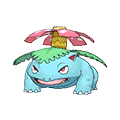

In [117]:
from IPython.display import Image, display

display(Image(filename="/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/images/venusaur.png"))

In [128]:
# from IPython.display import Image, display

# # def recommend(pika):
# #     # Find the index of the selected Pokémon
# #     idx = df[df['Name'].str.lower() == pika.lower()].index[0]

# #     # Get the top 5 most similar Pokémon (excluding itself)
# #     rc = sorted(
# #         list(enumerate(similar[idx])),
# #         key=lambda x: x[1],
# #         reverse=True
# #     )[1:6]

# def recommend(name):
#     name = name.lower()

#     idx = df[df['Name'].str.lower() == name].index[0]

#     rc = sorted(
#         list(enumerate(similar[idx])),
#         key=lambda x: x[1],
#         reverse=True
#     )[1:6]

#     for index, score in rc:
#         print(f"{df.iloc[index]['Name']}  ({score:.3f})")

#     # Display name and image
#     for i in rc:
#         name = df.iloc[i[0]]['Name']
#         print(name)

#         image_path = f"/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/images/{name.lower()}.png"

#         try:
#             display(Image(filename=image_path, width=150))
#         except:
#             print("Image not found:", image_path)

In [149]:
import os
from PIL import Image
import matplotlib.pyplot as plt
image_folder = "/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/images"

In [150]:
def recommend(pokemon):

    idx = df[df['Name'] == pokemon].index[0]

    rc = sorted(
        list(enumerate(similar[idx])),
        key=lambda x: x[1],
        reverse=True
    )[1:6]

    for i in rc:

        pokemon_name = df.iloc[i[0]]['Name']

        print(f"{pokemon_name} ({i[1]:.3f})")

       
        image_name = pokemon_name.lower()

        if "mega" in image_name:
            image_name = image_name.split("mega")[0]

        image_name = image_name.strip()

        image_path = os.path.join(image_folder, image_name + ".png")

        
        if os.path.exists(image_path):

            img = Image.open(image_path)

            plt.imshow(img)
            plt.axis("off")
            plt.show()

        else:

            print("Image not found:", image_path)

vileplume (0.984)


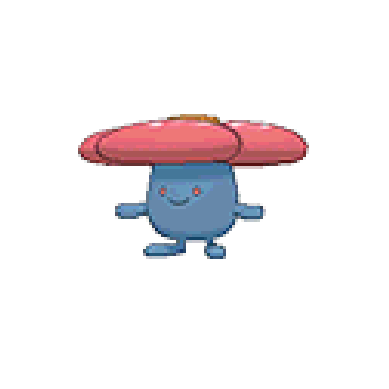

victreebel (0.974)


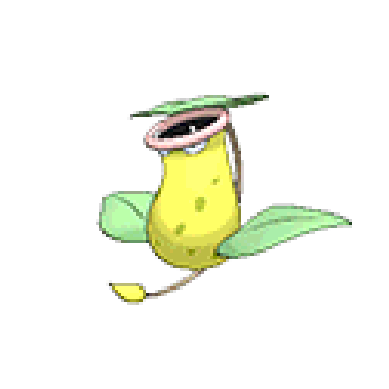

venusaurmega venusaur (0.971)


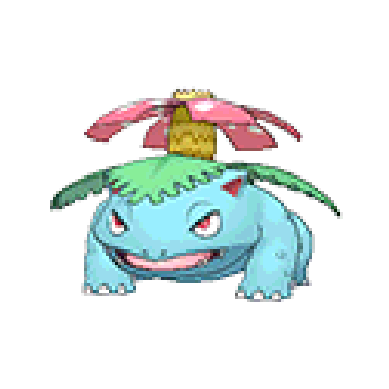

ivysaur (0.967)


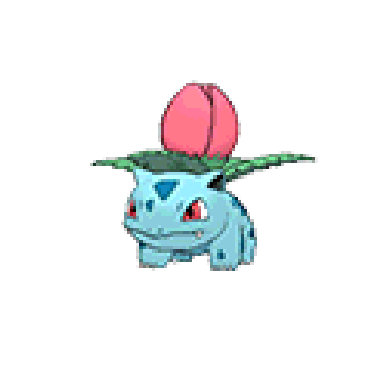

gloom (0.953)


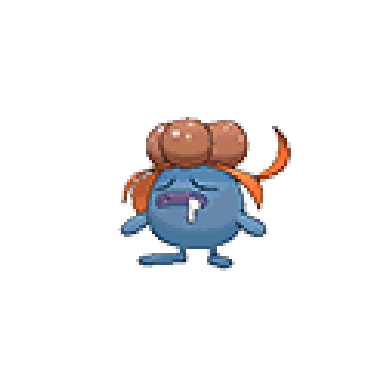

In [151]:
recommend("venusaur")

greninja (0.670)


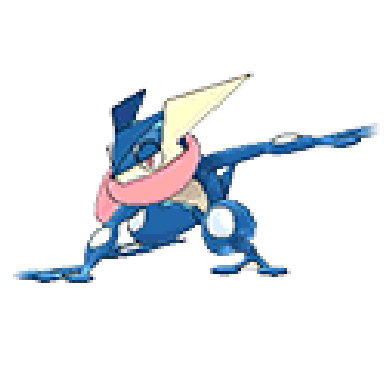

sharpedomega sharpedo (0.653)


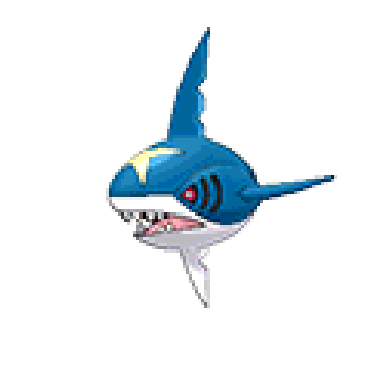

cacturne (0.614)


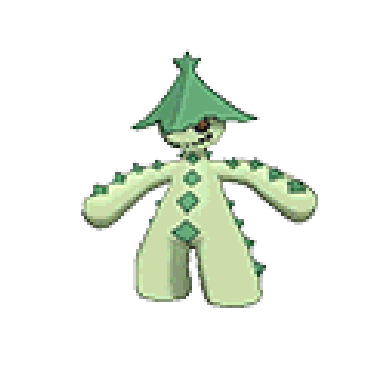

azelf (0.613)


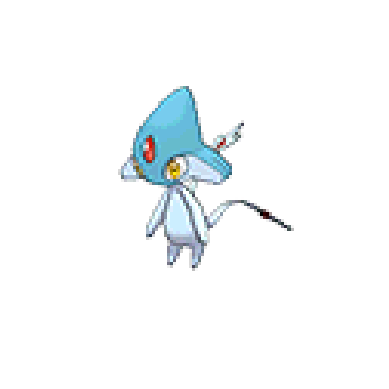

mesprit (0.610)


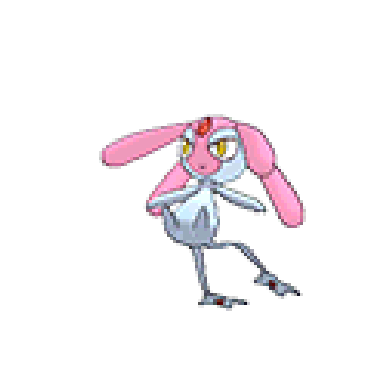

In [153]:
recommend("hoopahoopa unbound")